# Thesis graphs

In [1]:
import os
import sys
sys.path.append(os.path.abspath("../src"))
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import textwrap
import numpy as np
import random
import torch
from prsi.env import PrsiEnv
from prsi.agents.baselines import RandomAgent, GreedyAgent

from agents.dqn import DQNAgent
from agents.reinforce import REINFORCEAgent
from agents.ddqn import DoubleDQNAgent
from agents.monte_carlo import MonteCarloAgent
from agents.q_learning import QLearningAgent

In [2]:
def evaluate_agent(agent, episodes=1000, seed=42, opponent=GreedyAgent()):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    env = PrsiEnv(opponent=opponent)
    return agent.evaluate(env, episodes, opponent)


def format_strategy_name(name: str) -> str:
    """
    Parses custom hyperparameter folder names into a human-readable legend label.
    Example: 'seed42-gamma0.99-lr0.0001-bs32-base' -> 'Seed: 42, Gamma: 0.99, LR: 0.0001, Batch Size: 32, Baseline'
    """
    # Map prefixes to human-readable names. 
    # Ordered roughly from longest to shortest so 'mineps' matches before 'eps'
    mappings = {
        "mineps": "Minimum Epsilon",
        "selfplay": "Self-Play",
        "spfreq": "SP Freq",
        "decay": "Epsilon Decay",
        "gamma": "Gamma",
        "alpha": "Alpha",
        "trunc": "Truncated to",
        "hand_": "Hand option",
        "sub_": "Played subset",
        "seed": "Seed",
        "base": "Baseline",
        "norm": "Normalized Advantage",
        "targ": "Target Update Frequency",
        "eps": "Epsilon",
        "ent": "Entropy regularization",
        "hid": "Hidden",
        "lr": "Learning Rate",
        "bs": "Batch Size",
        "ev": "Every Visit"
    }
    
    parts = name.split('-')
    formatted_parts = []
    to_skip = {"gamma", "seed", "lr", "bs", "hand_", "sub_"} # skip what didn't change in experiments
    
    for part in parts:
        matched = False
        for key, label in mappings.items():
            if key in to_skip:
                    matched = True
                    continue # Skip adding this to formatted_parts completely
            if part.startswith(key):              
                val = part[len(key):]  # Extract whatever comes after the prefix

                if val:
                    # Clean up values slightly (e.g., count_truncated -> count truncated)
                    val = val.replace('_', ' ')
                    formatted_parts.append(f"{label}: {val}")
                else:
                    # If there's no value (like for 'base' or 'selfplay'), just add the label
                    formatted_parts.append(f"{label}")
                matched = True
                break
        
        # Fallback if a prefix wasn't in our dictionary
        if not matched:
            formatted_parts.append(part)
            
    return ", ".join(formatted_parts)

def plot_and_eval_algorithm(algo_name, agent_class, strategies_dir):
    if not os.path.exists(strategies_dir):
        print(f"Directory {strategies_dir} does not exist.")
        return

    strategies = sorted([d for d in os.listdir(strategies_dir) if os.path.isdir(os.path.join(strategies_dir, d))])
    
    fig, ax = plt.subplots(figsize=(18, 10))
    results = []
    
    for strategy in strategies:
        strategy_path = os.path.join(strategies_dir, strategy)
        log_path = os.path.join(strategy_path, "logs.csv")
        if not os.path.exists(log_path):
            continue
            
        df = pd.read_csv(log_path)
            
        # Format the strategy name to be human-readable, then wrap it
        readable_label = format_strategy_name(strategy)
        wrapped_label = textwrap.fill(readable_label, width=60)      
        
        ax.plot(df["episode"], df["batch_win_rate"], label=wrapped_label)
        
        # Evaluate
        try:
            agent = agent_class(path=strategy_path)
            win_rate = evaluate_agent(agent, opponent=GreedyAgent()) # Explicitly passing GreedyAgent
            results.append((win_rate, strategy, agent))
            print(f"Strategy {strategy}: {win_rate:.2%} win rate")
        except Exception as e:
            print(f"Could not evaluate {strategy}: {e}")
            
    # --- SIGNIFICANTLY INCREASED FONT SIZES ---
    ax.set_title(f"{algo_name} Training Win Rate", fontsize=28, pad=15)
    ax.set_xlabel("Episode", fontsize=24, labelpad=10)
    ax.set_ylabel("Win Rate", fontsize=24, labelpad=10)
    
    # Increase the size of the tick labels
    ax.tick_params(axis='both', which='major', labelsize=20)
    
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.8, zorder=0)
    
    # Place the legend below the graph with a much larger font size
    ax.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2, fontsize=18)
    ax.grid(True)
    
    # Leave slightly more margin at the bottom specifically for the larger legend
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.35) 
    
    # Save the graph
    save_dir = "images"
    os.makedirs(save_dir, exist_ok=True)
    filename = f"{algo_name.lower().replace(' ', '_')}_training.svg"
    plt.savefig(os.path.join(save_dir, filename), format='svg', bbox_inches='tight')
    
    plt.show()
    
    if not results:
        print(f"No evaluated strategies found for {algo_name}")
        return

    best_win_rate, best_strategy, best_agent = max(results, key=lambda x: x[0])
    
    # Eval against RandomAgent
    random_win_rate = evaluate_agent(best_agent, opponent=RandomAgent())

    # --- Print all win rates sorted before best agent ---
    print(f"\n--- {algo_name} Summary (Against GreedyAgent) ---")
    # Sort descending by win rate so the best ones are at the top
    for win_rate, strategy, _ in sorted(results, key=lambda x: x[0], reverse=True):
        print(f"{win_rate:7.2%} | {strategy}")
    print("--------------------------------------------------\n")

    print(f"Best strategy: {best_strategy}.")
    print(f"Best {algo_name} agent against GreedyAgent: {best_win_rate:.2%} win rate")
    print(f"Best {algo_name} agent against RandomAgent: {random_win_rate:.2%} win rate")

## Monte Carlo

Loading model from ../src/agent_strategies/monte_carlo/seed42-eps0.05-gamma0.99-hand_count_truncated-trunc4-sub_specials/model.pkl
Model loaded successfully!
Evaluation: 477/1000 wins (47.70%)
Strategy seed42-eps0.05-gamma0.99-hand_count_truncated-trunc4-sub_specials: 47.70% win rate
Loading model from ../src/agent_strategies/monte_carlo/seed42-eps0.1-gamma0.99-ev-hand_count_truncated-trunc4-sub_specials/model.pkl
Model loaded successfully!
Evaluation: 484/1000 wins (48.40%)
Strategy seed42-eps0.1-gamma0.99-ev-hand_count_truncated-trunc4-sub_specials: 48.40% win rate
Loading model from ../src/agent_strategies/monte_carlo/seed42-eps0.1-gamma0.99-hand_count_truncated-trunc4-sub_specials/model.pkl
Model loaded successfully!
Evaluation: 498/1000 wins (49.80%)
Strategy seed42-eps0.1-gamma0.99-hand_count_truncated-trunc4-sub_specials: 49.80% win rate
Loading model from ../src/agent_strategies/monte_carlo/seed42-eps0.5-decay0.99999-mineps0.001-gamma0.99-alpha0.01-hand_count_truncated-trunc4-s

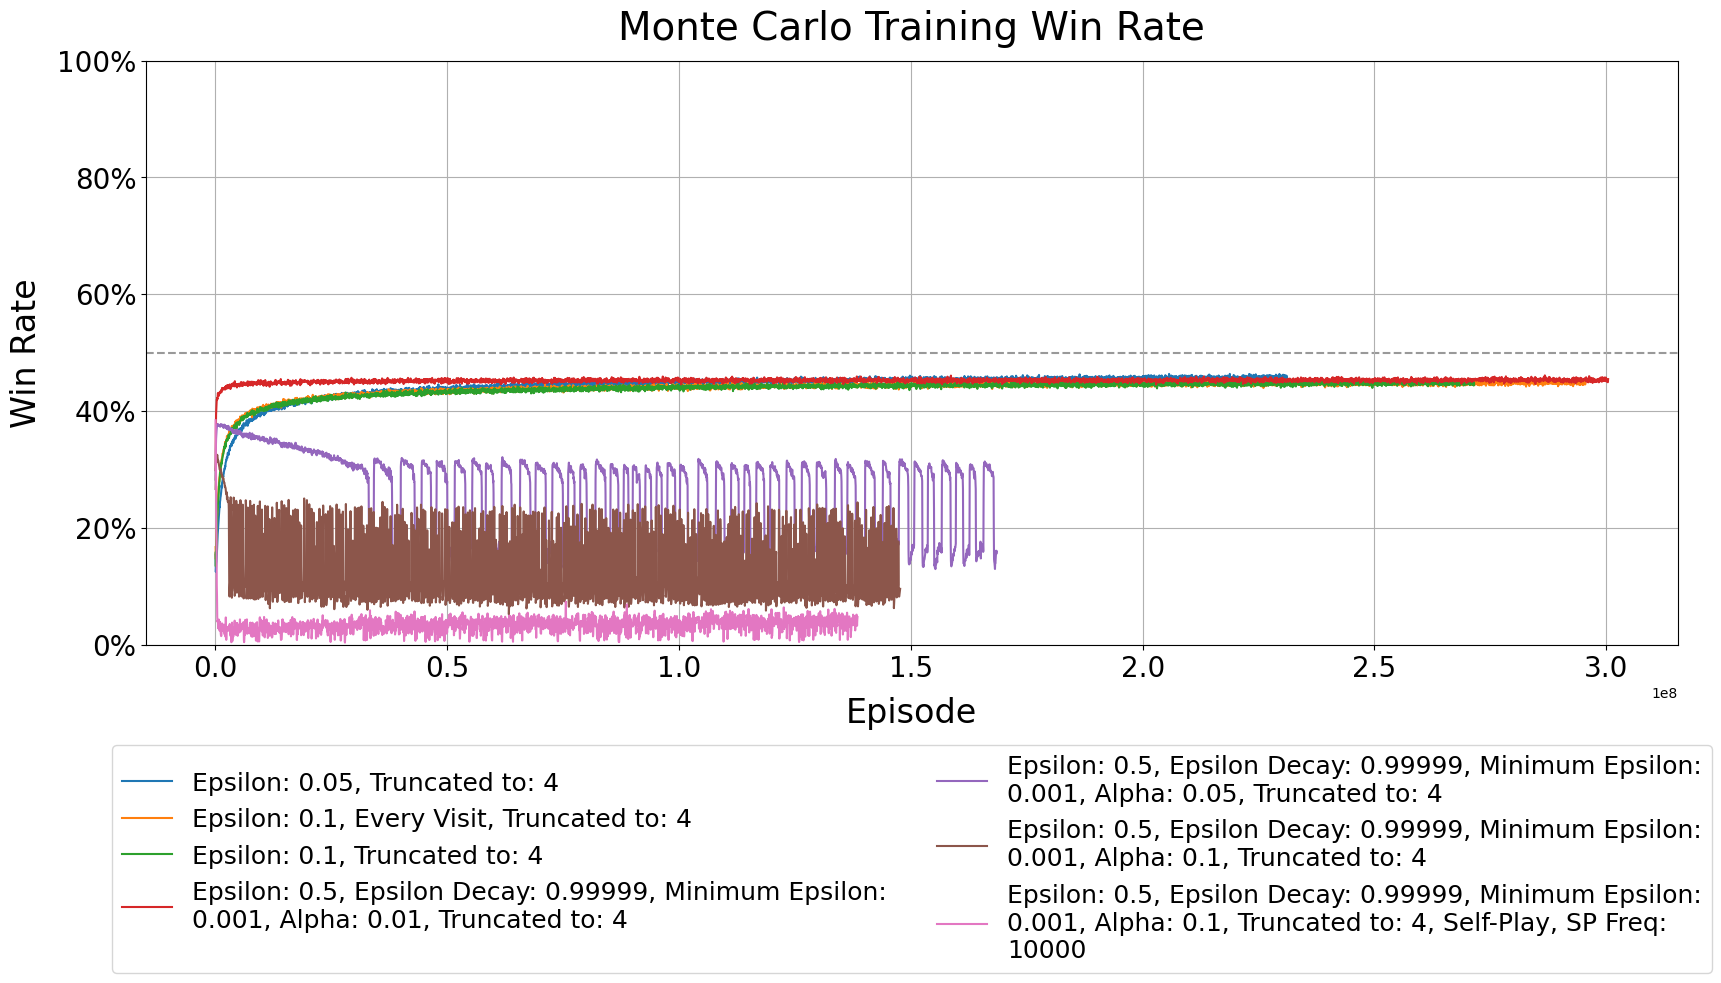

Evaluation: 920/1000 wins (92.00%)

--- Monte Carlo Summary (Against GreedyAgent) ---
 49.80% | seed42-eps0.1-gamma0.99-hand_count_truncated-trunc4-sub_specials
 48.40% | seed42-eps0.1-gamma0.99-ev-hand_count_truncated-trunc4-sub_specials
 47.70% | seed42-eps0.05-gamma0.99-hand_count_truncated-trunc4-sub_specials
 45.20% | seed42-eps0.5-decay0.99999-mineps0.001-gamma0.99-alpha0.01-hand_count_truncated-trunc4-sub_specials
 16.10% | seed42-eps0.5-decay0.99999-mineps0.001-gamma0.99-alpha0.05-hand_count_truncated-trunc4-sub_specials
  9.00% | seed42-eps0.5-decay0.99999-mineps0.001-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials
  6.80% | seed42-eps0.5-decay0.99999-mineps0.001-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials-selfplay-spfreq10000
--------------------------------------------------

Best strategy: seed42-eps0.1-gamma0.99-hand_count_truncated-trunc4-sub_specials.
Best Monte Carlo agent against GreedyAgent: 49.80% win rate
Best Monte Carlo agent against Ra

In [3]:
plot_and_eval_algorithm("Monte Carlo", MonteCarloAgent, "../src/agent_strategies/monte_carlo")

## Q-Learning

Loading model from ../src/agent_strategies/q_learning/seed42-eps0.05-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials/model.pkl
Model loaded successfully!
Evaluation: 335/1000 wins (33.50%)
Strategy seed42-eps0.05-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials: 33.50% win rate
Loading model from ../src/agent_strategies/q_learning/seed42-eps0.1-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials/model.pkl
Model loaded successfully!
Evaluation: 401/1000 wins (40.10%)
Strategy seed42-eps0.1-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials: 40.10% win rate
Loading model from ../src/agent_strategies/q_learning/seed42-eps0.5-decay0.99999-mineps0.001-gamma0.99-alpha0.01-hand_count_truncated-trunc4-sub_specials/model.pkl
Model loaded successfully!
Evaluation: 348/1000 wins (34.80%)
Strategy seed42-eps0.5-decay0.99999-mineps0.001-gamma0.99-alpha0.01-hand_count_truncated-trunc4-sub_specials: 34.80% win rate
Loading model from ../src/agent_strategies/q_l

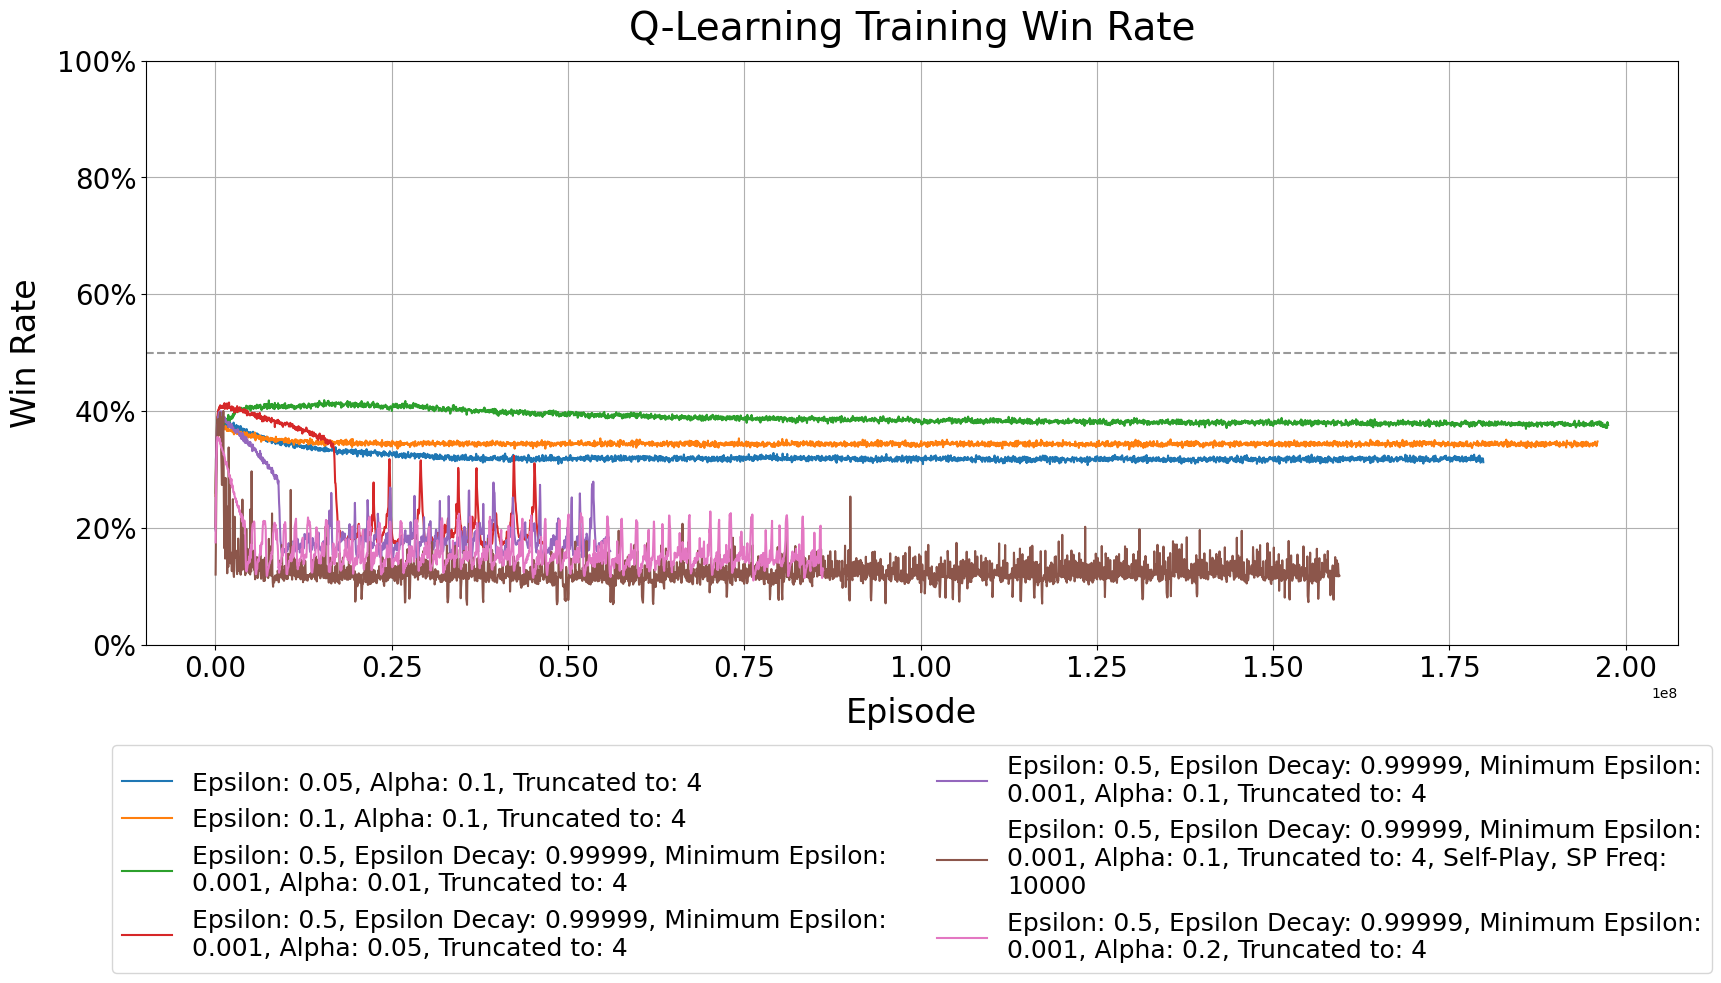

Evaluation: 880/1000 wins (88.00%)

--- Q-Learning Summary (Against GreedyAgent) ---
 40.10% | seed42-eps0.1-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials
 34.80% | seed42-eps0.5-decay0.99999-mineps0.001-gamma0.99-alpha0.01-hand_count_truncated-trunc4-sub_specials
 33.50% | seed42-eps0.05-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials
 16.60% | seed42-eps0.5-decay0.99999-mineps0.001-gamma0.99-alpha0.05-hand_count_truncated-trunc4-sub_specials
 15.10% | seed42-eps0.5-decay0.99999-mineps0.001-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials
 15.00% | seed42-eps0.5-decay0.99999-mineps0.001-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials-selfplay-spfreq10000
 13.10% | seed42-eps0.5-decay0.99999-mineps0.001-gamma0.99-alpha0.2-hand_count_truncated-trunc4-sub_specials
--------------------------------------------------

Best strategy: seed42-eps0.1-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials.
Best Q-Learning agent against Greedy

In [4]:
plot_and_eval_algorithm("Q-Learning", QLearningAgent, "../src/agent_strategies/q_learning")

## DQN

Loading model from ../src/agent_strategies/dqn/seed42-eps0.05-gamma0.99-lr5e-05-bs32-targ100-hid2x1024-hand_full-sub_all/model.pth
Model loaded successfully!
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No

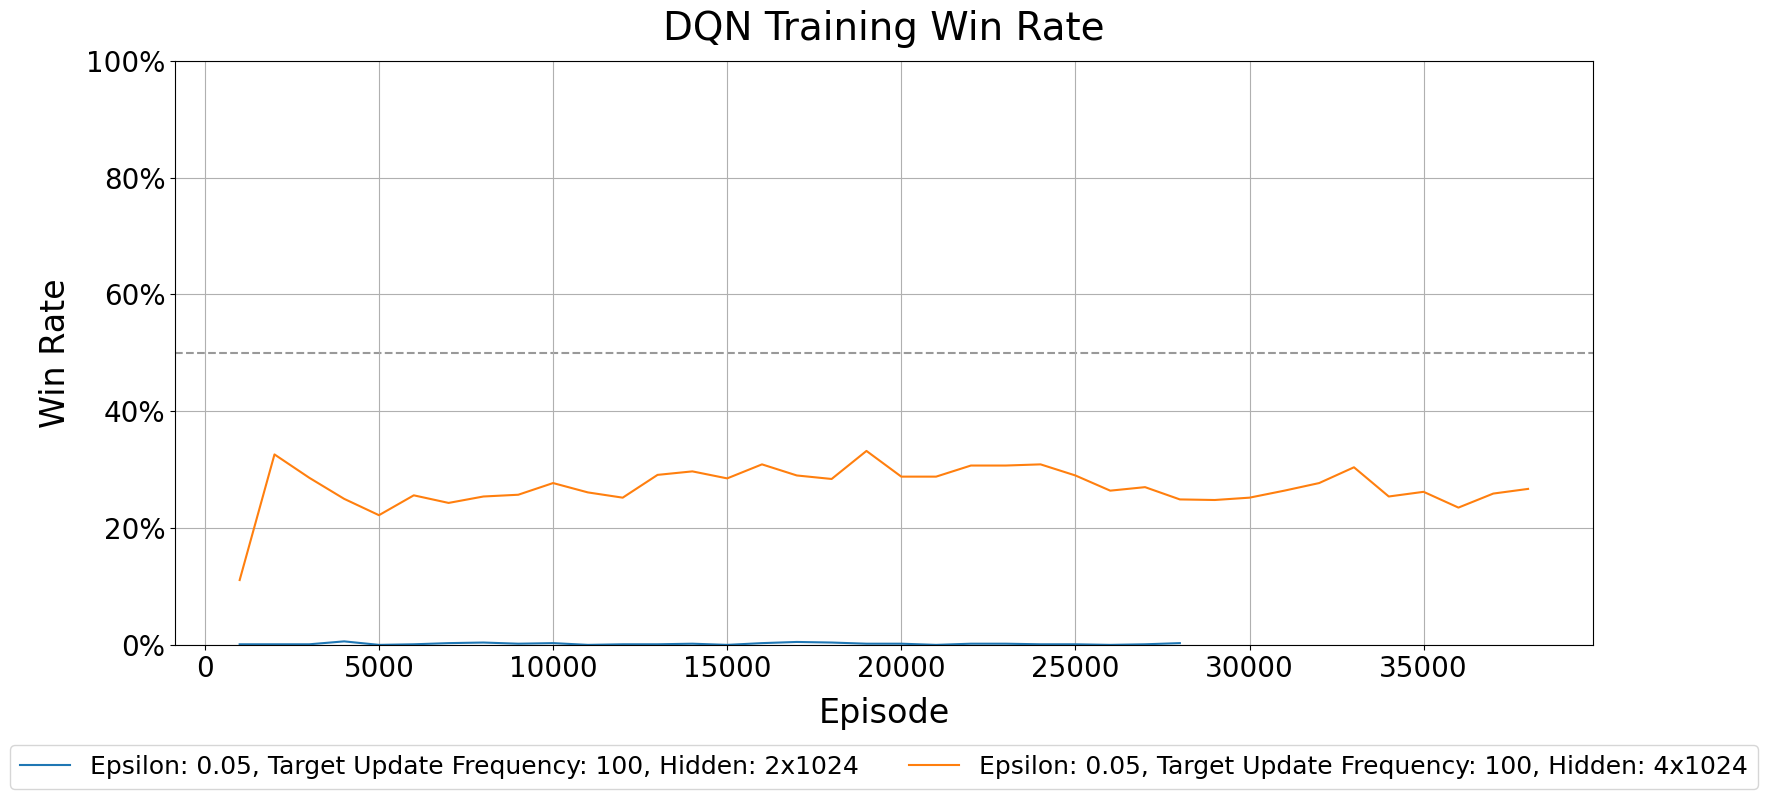

No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available t

In [5]:
plot_and_eval_algorithm("DQN", DQNAgent, "../src/agent_strategies/dqn")

## Double DQN

Loading model from ../src/agent_strategies/ddqn/seed42-eps0.05-gamma0.99-lr5e-05-bs32-targ100-hid4x1024-hand_full-sub_all/model.pth
Model loaded successfully!
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
N

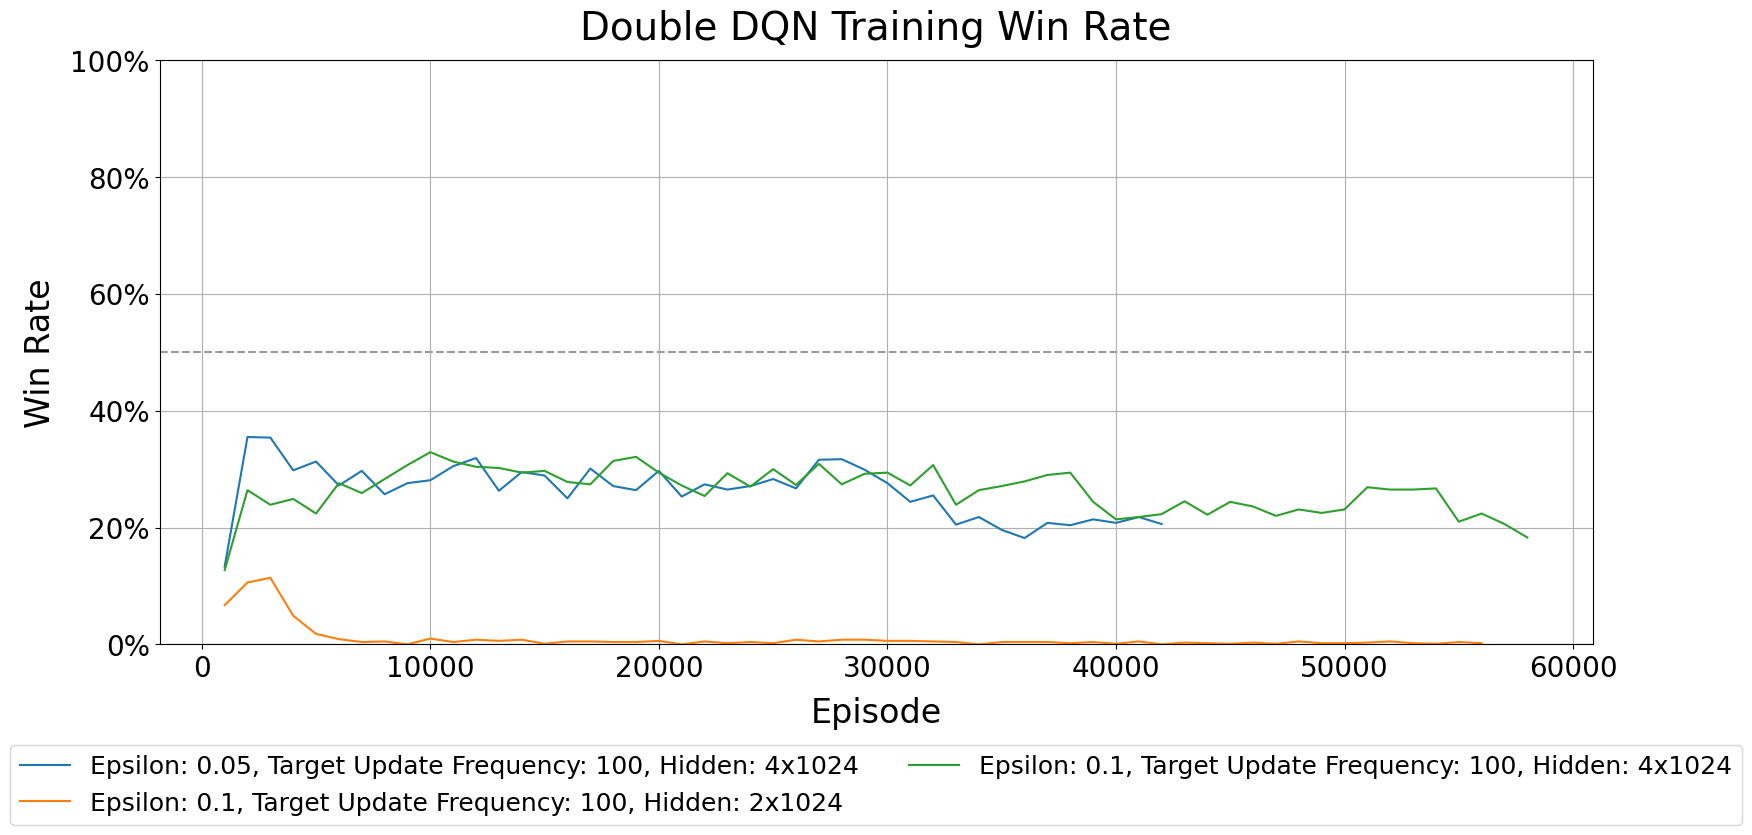

No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available t

In [6]:
plot_and_eval_algorithm("Double DQN", DoubleDQNAgent, "../src/agent_strategies/ddqn")

## REINFORCE

Loading model from ../src/agent_strategies/reinforce/seed42-gamma0.99-lr0.0001-bs32-ent0.001-base-hid2x1024-hand_full-sub_all/model.pth
Model loaded successfully!
Evaluation: 551/1000 wins (55.10%)
Strategy seed42-gamma0.99-lr0.0001-bs32-ent0.001-base-hid2x1024-hand_full-sub_all: 55.10% win rate
Loading model from ../src/agent_strategies/reinforce/seed42-gamma0.99-lr0.0001-bs32-ent0.01-base-hid2x1024-hand_full-sub_all/model.pth
Model loaded successfully!
Evaluation: 636/1000 wins (63.60%)
Strategy seed42-gamma0.99-lr0.0001-bs32-ent0.01-base-hid2x1024-hand_full-sub_all: 63.60% win rate
Loading model from ../src/agent_strategies/reinforce/seed42-gamma0.99-lr0.0001-bs32-ent0.01-hid2x1024-hand_full-sub_all/model.pth
Model loaded successfully!
Evaluation: 621/1000 wins (62.10%)
Strategy seed42-gamma0.99-lr0.0001-bs32-ent0.01-hid2x1024-hand_full-sub_all: 62.10% win rate
Loading model from ../src/agent_strategies/reinforce/seed42-gamma0.99-lr0.0001-bs32-ent0.05-base-hid2x1024-hand_full-sub_al

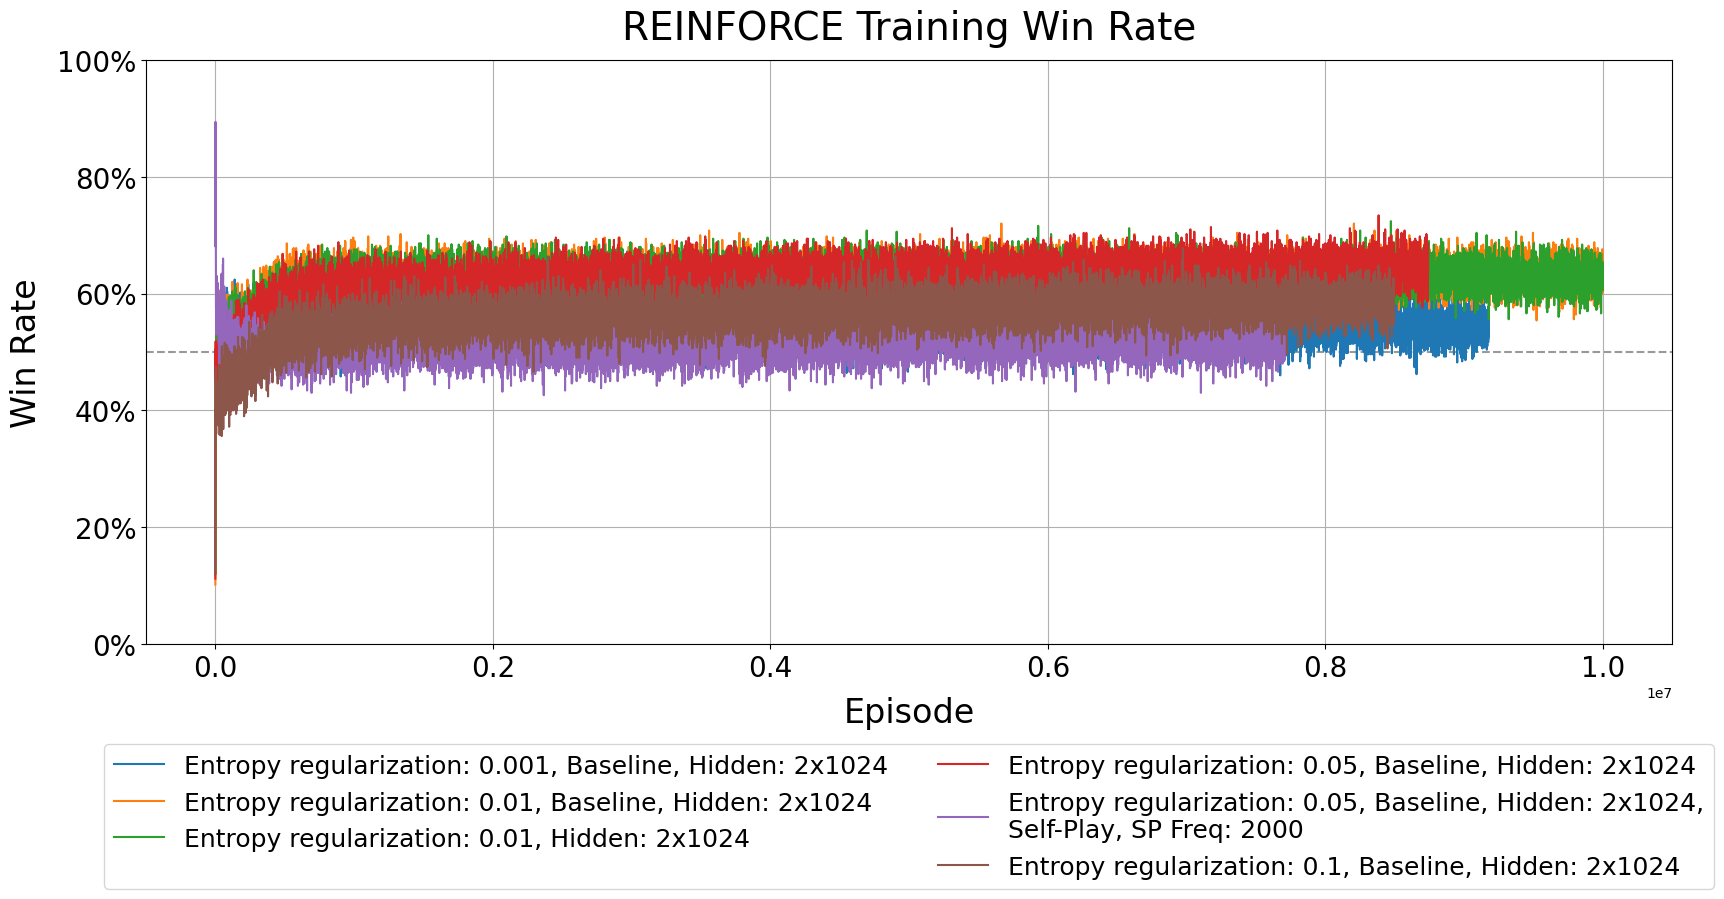

Evaluation: 957/1000 wins (95.70%)

--- REINFORCE Summary (Against GreedyAgent) ---
 64.90% | seed42-gamma0.99-lr0.0001-bs32-ent0.05-base-hid2x1024-hand_full-sub_all
 63.60% | seed42-gamma0.99-lr0.0001-bs32-ent0.01-base-hid2x1024-hand_full-sub_all
 62.40% | seed42-gamma0.99-lr0.0001-bs32-ent0.05-base-hid2x1024-hand_full-sub_all-selfplay-spfreq2000
 62.10% | seed42-gamma0.99-lr0.0001-bs32-ent0.01-hid2x1024-hand_full-sub_all
 57.40% | seed42-gamma0.99-lr0.0001-bs32-ent0.1-base-hid2x1024-hand_full-sub_all
 55.10% | seed42-gamma0.99-lr0.0001-bs32-ent0.001-base-hid2x1024-hand_full-sub_all
--------------------------------------------------

Best strategy: seed42-gamma0.99-lr0.0001-bs32-ent0.05-base-hid2x1024-hand_full-sub_all.
Best REINFORCE agent against GreedyAgent: 64.90% win rate
Best REINFORCE agent against RandomAgent: 95.70% win rate


In [7]:
plot_and_eval_algorithm("REINFORCE", REINFORCEAgent, "../src/agent_strategies/reinforce")